<a href="https://colab.research.google.com/github/stevehadd/python_utils/blob/main/google_colab/ERA5_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading a Remote Zarr file - ERA5 ARCO example

[Zarr](https://zarr.readthedocs.io/) is an increasingly popular format for storing gridded environmental science data, especially when working on cloud environments. The nature of a zarr, with consolidated metadat which enables interaction with a dataset as a unified whole, data divided into separate files called *chunks* to enable parallel read and write, which suits a massively parallel distributed file system like the object stores used by cloud providers, makes it efficient and intuive for many machine-learning platforms and workflows.

PyEarthTools provides a data accessor class for zarr files. As PyEarthTools uses xarray for data I/O, which through fsspec supports loading data directly from remote sources, it can load data from such sources.


In [1]:
# uncomment this cell to install pyearthtools on colab
!git clone https://github.com/ACCESS-Community-Hub/PyEarthTools.git /tmp/pyearthtools; cd /tmp/pyearthtools/; pip install packages/utils; pip install packages/data[all]; pip install packages/training[all]; pip install packages/pipeline[all]; pip install packages/tutorial; pip install packages/bundled_models/fourcastnext; pip install packages/zoo

Cloning into '/tmp/pyearthtools'...
remote: Enumerating objects: 14136, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 14136 (delta 23), reused 12 (delta 4), pack-reused 14059 (from 2)
Receiving objects: 100% (14136/14136), 89.84 MiB | 19.01 MiB/s, done.
Resolving deltas: 100% (8518/8518), done.
Processing ./packages/utils
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 73.7 MB/s eta 0:00:00
  Created wheel for pyearthtools-utils: filename=pyearthtools_utils-0.6.1-py3-none-any.whl size=63431 sha256=5fd8d2d168d8d35939ce69242979b8a7f67d9972fcaa35b81f58cbb7244771ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-uvcwa1e4/wheels/70/38/a1/4ae505914aa560e947d37fe6f1114d53e519b9a5a924594f5f
Successfully built pyearthtools-utils
Processing ./packages/data
  Installing build dependencie

### Set up imports for demo

In [171]:
import datetime
import functools
import math

In [193]:
import numpy

In [2]:
import xarray

In [3]:
import matplotlib.pyplot
import cartopy

In [4]:
import pyearthtools.data

In [82]:
from pyearthtools.data import TimeDelta, Petdt

In [85]:
import pyearthtools.pipeline

In [89]:
import torch

## Set up the accessor

Fore this demo we will be using the copy of the [ECMWF ERA5 Reanalsyis dataset](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-pressure-levels?tab=overview) hosted by [Google Research](https://github.com/google-research/arco-era5) on the Google Cloud Storage system.

In [6]:
remote_url = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'

In [7]:
zarr_opts = {'chunks': None, 'storage_options': {'token': 'anon'}}

Usually we are only interested in a subset of the data, so we can select a particular time, pressure levels and set of variables that we want to us

In [67]:
ghana_extents = {
    'latitude': (4.5,12.3),
    'longitude': (-3.8, 4.0),
}

In [68]:
ghana_pet_box = (ghana_extents['latitude'][0],
                 ghana_extents['latitude'][1],
                 ghana_extents['longitude'][0],
                 ghana_extents['longitude'][1],
                )

In [69]:
select_variables = ['temperature', 'specific_humidity']
select_pressure_levels = [200, 500, 700, 850, 1000]
select_time = ('2024-04-01','2025-09-30')

In [70]:
select_dict = {
    'level': select_pressure_levels,
    'time': slice(*select_time),
}

In [71]:
era5_accessor = pyearthtools.data.archive.ZarrTimeIndex(
       remote_url,
       variables=select_variables,
       open_kwargs=zarr_opts,
    remote=True,
    transforms=pyearthtools.data.transforms.TransformCollection([
        pyearthtools.data.transforms.coordinates.StandardLongitude(),
        pyearthtools.data.transform.coordinates.Select(select_dict),
        pyearthtools.data.transform.region.Bounding(ghana_extents['latitude'][0],ghana_extents['latitude'][1], ghana_extents['longitude'][0], ghana_extents['longitude'][1])
    ]),
    )

## Using the data of interest
We can now look at the xarray dataset through the time index function. If we do this, the xarray lazy loading paradigm means only the metadata will have been downloaded form the remote location, until we try to do some thing which requires the data. For example after exmaing the metadata, we will then plot some of the data which will take longer as the data will be transfered from the remote location. This will be quite efficient as only the chunks pertaining to the data selected (variables, time period, spatial region) will be transferred.

In [72]:
select_dt = datetime.datetime(2025,7,16,17,0)

In [73]:
era5_accessor[select_dt]

<xarray.Dataset> Size: 41kB
Dimensions:            (time: 1, level: 5, latitude: 32, longitude: 32)
Coordinates:
  * time               (time) datetime64[ns] 8B 2025-07-16T17:00:00
  * level              (level) int64 40B 200 500 700 850 1000
  * latitude           (latitude) float32 128B 12.25 12.0 11.75 ... 5.0 4.75 4.5
  * longitude          (longitude) float32 128B -3.75 -3.5 -3.25 ... 3.75 4.0
Data variables:
    specific_humidity  (time, level, latitude, longitude) float32 20kB ...
    temperature        (time, level, latitude, longitude) float32 20kB ...
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2026-06-03 02:45:44.987382+00:00
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-05-28

In [74]:
float(era5_accessor[select_dt]['latitude'].min()), float(era5_accessor[select_dt]['latitude'].max()), float(era5_accessor[select_dt]['longitude'].min()), float(era5_accessor[select_dt]['longitude'].max())

(4.5, 12.25, -3.75, 4.0)

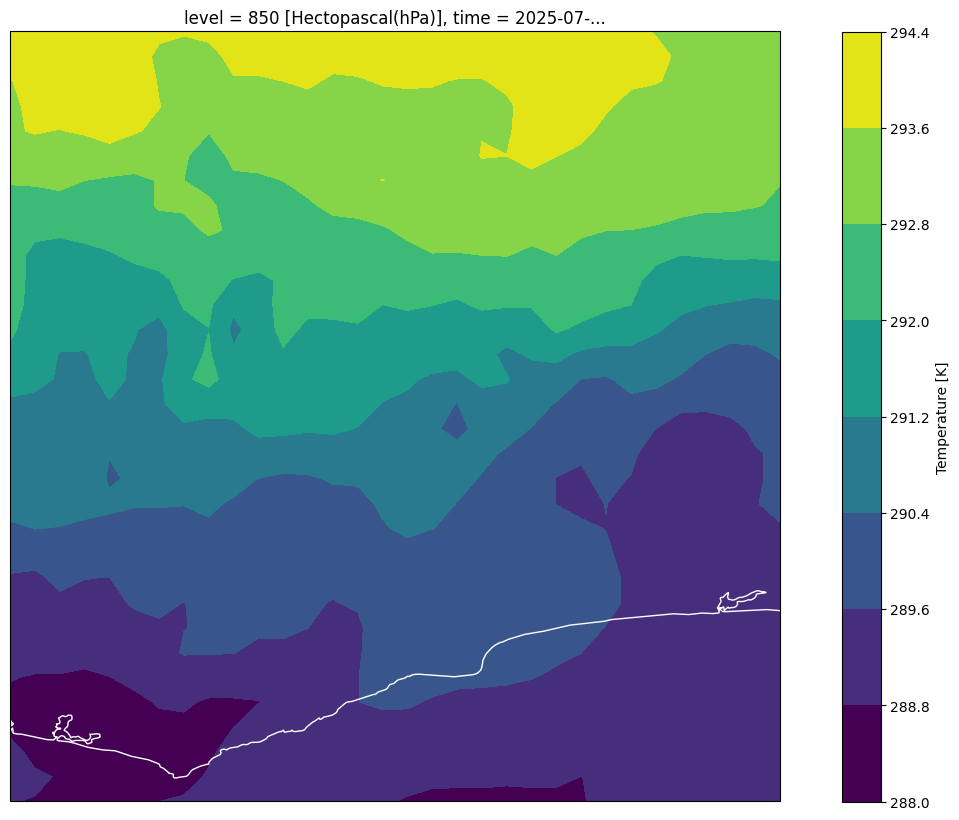

In [75]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))
ax1=fig1.add_subplot(1,1,1,projection=cartopy.crs.PlateCarree())
era5_accessor[select_dt]['temperature'].sel(level=850)[0].plot.contourf(ax=ax1)
ax1.coastlines(color='w')

In [132]:
ew4_era5_prep = pyearthtools.pipeline.Pipeline(
    era5_accessor,
    pyearthtools.pipeline.pipelines.Cache('/tmp')
    exceptions_to_ignore=pyearthtools.data.exceptions.DataNotFoundError,
)

In [187]:
ew4_era5_prep[select_dt]

<xarray.Dataset> Size: 41kB
Dimensions:            (time: 1, level: 5, latitude: 32, longitude: 32)
Coordinates:
  * time               (time) datetime64[ns] 8B 2025-07-16T17:00:00
  * level              (level) int64 40B 200 500 700 850 1000
  * latitude           (latitude) float32 128B 12.25 12.0 11.75 ... 5.0 4.75 4.5
  * longitude          (longitude) float32 128B -3.75 -3.5 -3.25 ... 3.75 4.0
Data variables:
    specific_humidity  (time, level, latitude, longitude) float32 20kB ...
    temperature        (time, level, latitude, longitude) float32 20kB ...
Attributes:
    valid_time_start:       1940-01-01
    last_updated:           2026-06-03 02:45:44.987382+00:00
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-05-28

In [189]:
ew4_era5_ml = pyearthtools.pipeline.Pipeline(
        pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten(['level']),
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
)

In [135]:
(ew4_era5_prep | ew4_era5_ml)['2025-07-05 16:00'].shape

(1, 10, 32, 32)

In [190]:
train_range = pyearthtools.pipeline.Pipeline(
    pyearthtools.pipeline.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('1 hour')),
    iterator=pyearthtools.pipeline.iterators.DateRange('20250501T00', '20250701T00', interval='1 hour').randomise(),
    exceptions_to_ignore=pyearthtools.data.exceptions.DataNotFoundError,
)
val_range = pyearthtools.pipeline.Pipeline(
    pyearthtools.pipeline.modifications.TemporalWindow(prior_indexes=[0,], posterior_indexes=[0,], timedelta=TimeDelta('1 hour')),
    iterator=pyearthtools.pipeline.iterators.DateRange('20250701T00', '20250801T00', interval='1 hour'),
    exceptions_to_ignore=pyearthtools.data.exceptions.DataNotFoundError,
)

Calculated indexes


In [191]:
ew4_era5_train_pipe = ew4_era5_prep | ew4_era5_ml | train_range
ew4_era5_val_pipe = ew4_era5_prep | ew4_era5_ml | val_range

In [182]:
predictor, target = ew4_era5_val_pipe[select_dt]

In [183]:
predictor, target = next(iter(ew4_era5_val_pipe))

In [184]:
predictor[0].shape

(1, 10, 32, 32)

In [185]:
target[0].shape

(1, 10, 32, 32)

In [90]:
# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [144]:
sample_tensor = torch.tensor(predictor[0], dtype=torch.float32).to(device)

In [145]:
sample_tensor.shape

torch.Size([1, 10, 32, 32])

In [147]:
torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=10,
                            out_channels=16,
                            kernel_size=3,
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=16,
                            out_channels=32,
                            kernel_size=3,
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
).to(device)(sample_tensor).shape

torch.Size([1, 32, 8, 8])

In [159]:
class Era5AutoEncoder(torch.nn.Module):
    def __init__(self, input_channels,):
        super().__init__()

        # we have "hard coded" a lot of the architecture hyperparameters in our model class.
        # Usually you want want to make these arguments for the class so you can vary hyperparameters more easily.
        # Hard coding here makes it easier to follow the architecture definition in the tutorial

        self._num_channels = [input_channels, 16,32]
        self._latent_array_dims = (-1,self._num_channels[-1],8,8)
        self._prelatent_size = functools.reduce(lambda a,b:a*b, self._latent_array_dims[1:])
        # self._latent_size = 500

        self._encoder = self._get_encoder()
        self._decoder = self._get_decoder()

    def _get_encoder(self, ):

        encoder = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=self._num_channels[0],
                            out_channels=self._num_channels[1],
                            kernel_size=3,
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=self._num_channels[1],
                            out_channels=self._num_channels[2],
                            kernel_size=3,
                            padding=1,
                            stride=2,
                           ),
            torch.nn.ReLU(),
            torch.nn.Flatten(1, -1),
            )
        return encoder

    def _get_decoder(self):
        """
        """
        decoder = torch.nn.Sequential(
            torch.nn.ConvTranspose2d(in_channels=self._num_channels[2], out_channels=self._num_channels[1], kernel_size=2,stride=2),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose2d(in_channels=self._num_channels[1], out_channels=self._num_channels[0], kernel_size=2,stride=2),
        )
        return decoder

    def forward(self, x):

        # Get latent representation
        latent = self._encoder(x)

        # Reconstruct input
        reconstructed = self._decoder(latent.view(self._latent_array_dims))

        return reconstructed

In [160]:
num_channels = sample_tensor.shape[1]
num_channels

10

In [163]:
era5_autoencoder = Era5AutoEncoder(num_channels).to(device)

In [167]:
sample_tensor.shape,era5_autoencoder.forward(sample_tensor).shape

(torch.Size([1, 10, 32, 32]), torch.Size([1, 10, 32, 32]))

In [168]:
# Loss function and optimizer
loss_function = torch.nn.MSELoss()

optimizer = torch.optim.Adam(era5_autoencoder.parameters(),
                             lr=5e-3)

In [ ]:
num_epochs = 2

In [172]:
num_samples = len(ew4_era5_train_pipe)
batch_size=8
num_batches = math.ceil(num_samples / batch_size)
num_batches

366

In [ ]:
def get_batch_tensors(batch_size, ds_iterator, device):
    """
    Get a torch tensor for target and predictors from a pyearthtools pipeline iterator
    """
    predictor_batch_list = []
    target_batch_list = []
    for ix1 in range(batch_size):
        pred_sample, target_sample = next(ds_iterator)
        predictor_batch_list += [pred_sample[0]]
        target_batch_list += [target_sample[0]]

    # create numpy array of a batch
    predictor_array = numpy.concat(predictor_batch_list, axis=0)
    target_array = numpy.concat(target_batch_list, axis=0)

    # convert to a tensor and send to gpu
    predictor_gpu_tensor = torch.tensor(
        predictor_array,
        dtype=torch.float32,
    ).to(device)
    target_gpu_tensor = torch.tensor(
        target_array,
        dtype=torch.float32,
    ).to(device)

    return predictor_gpu_tensor, target_gpu_tensor



In [195]:
get_batch_tensors(2, iter(ew4_era5_val_pipe), device)[0]

0
1


tensor([[[[9.3750e-05, 9.1728e-05, 8.9019e-05,  ..., 6.7135e-05,
           8.5500e-05, 9.9545e-05],
          [8.7639e-05, 8.7408e-05, 8.5816e-05,  ..., 6.5886e-05,
           7.9757e-05, 9.1714e-05],
          [8.3267e-05, 8.3220e-05, 8.3022e-05,  ..., 6.0751e-05,
           7.3504e-05, 8.1472e-05],
          ...,
          [5.6845e-05, 5.4880e-05, 5.2750e-05,  ..., 7.3363e-05,
           7.3797e-05, 7.3259e-05],
          [5.0819e-05, 4.8741e-05, 4.6611e-05,  ..., 7.4183e-05,
           7.3029e-05, 7.2463e-05],
          [4.6027e-05, 4.3949e-05, 4.1895e-05,  ..., 7.4631e-05,
           7.3476e-05, 7.2411e-05]],

         [[4.1816e-03, 4.4544e-03, 4.4364e-03,  ..., 2.5832e-03,
           2.6003e-03, 2.6041e-03],
          [4.3067e-03, 4.4520e-03, 4.4500e-03,  ..., 2.2565e-03,
           2.3855e-03, 2.4434e-03],
          [4.2993e-03, 4.4478e-03, 4.3542e-03,  ..., 2.6189e-03,
           2.6934e-03, 2.5327e-03],
          ...,
          [1.8483e-03, 1.8395e-03, 1.8344e-03,  ..., 1.0710

In [ ]:
test_it = iter(ew4_era5_val_pipe)
era5_autoencoder.forward(get_batch_tensors(batch_size, test_it, device)[0]).shape, era5_autoencoder.forward(get_batch_tensors(batch_size, test_it, device)[0]).shape

0
1
2
3
4
5
6
7
0
1
2


In [ ]:
%%time
for epoch_num in range(num_epochs):
    print(epoch_num)
    epoch_train_loss = 0.0
    epoch_val_loss = 0.0

    imerg_train_iter = iter(ew4_imerg_train_pipe)

    for batch_ix in range(num_batches):

        predictor_gpu_tensor, target_gpu_tensor = get_batch_tensors(batch_size, imerg_train_iter, device)

        if (batch_ix % 100) == 0:
            print(batch_ix)

        # do training for batch
        optimizer.zero_grad()
        predictions = era5_autoencoder.forward(predictor_gpu_tensor)
        loss_batch = loss_function(predictions, target_gpu_tensor)
        loss_batch.backward()
        optimizer.step()
        epoch_train_loss += loss_batch.to('cpu').item()
    epoch_train_loss /= num_batches

    # calculate loss on validation data
    for val_predictor, val_target in ew4_era5_val_pipe:
        val_pred_tensor = torch.tensor(val_predictor[0], dtype=torch.float32).to(device)
        predictions_val = era5_autoencoder.forward( val_pred_tensor)
        val_target_tensor = torch.tensor(val_target[0], dtype=torch.float32).to(device)
        loss_batch_val = loss_function(predictions_val, val_target_tensor)
        epoch_val_loss += loss_batch_val.to('cpu').item()

    epoch_val_loss /= len(ew4_era5_val_pipe)

    print(epoch_train_loss)
    print(epoch_val_loss)






In [1]:
import scores

In [ ]:
val_rmse_list = []
for predictor, target in ew4_era5_val_pipe:
    val_prediction_arr = era5_autoencoder.forward(torch.tensor(predictor[0], dtype=torch.float32).to(device)).to("cpu").detach().numpy()
    val_rmse_list += [scores.continuous.rmse(predictor[0],
                                             val_prediction_arr)]

In [ ]:
val_rmse = numpy.mean(val_rmse_list)

In [ ]:
val_rmse

In [ ]:
predictor, target = ew4_era5_val_pipe['2025-07-23 15:00']

In [ ]:
pred_gpu = target_gpu = torch.tensor(
    predictor[0],
    dtype=torch.float32,
).to(device)
target_gpu = torch.tensor(
    target[0],
    dtype=torch.float32,
).to(device)

In [ ]:
model_prediction_array = era5_autoencoder.forward(torch.tensor(
    predictor[0],
    dtype=torch.float32,
).to(device)).to("cpu").detach().numpy()

In [ ]:
input_ds = ew4_era5_ml.reversed(predictor[0])
truth_ds = ew4_era5_ml.reversed(target[0])
model_prediction = ew4_era5_ml.reversed(model_prediction_array)

In [ ]:
(model_prediction['t'] - truth_ds['t']).plot.hist()

In [ ]:
plot_kwargs = {'cmap':'viridis', 'vmin':0.0, 'vmax':5.0}

In [ ]:
(model_prediction['t'] - truth_ds['t'])[0].plot.contourf(**plot_kwargs)

In [ ]:
fig1 = matplotlib.pyplot.figure(figsize=(18,6))

ax1=fig1.add_subplot(1,3,1,projection=cartopy.crs.PlateCarree())
input_ds['t'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')

ax1=fig1.add_subplot(1,3,2,projection=cartopy.crs.PlateCarree())
model_prediction['t'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')


ax1=fig1.add_subplot(1,3,3,projection=cartopy.crs.PlateCarree())
truth_ds['t'][0].plot.contourf(ax=ax1, **plot_kwargs)
ax1.coastlines(color='w')
